# Phase 2: AdaFoB Hypothesis Validation Pilot

This notebook validates two core hypotheses of the AdaFoB project using **frozen SAM ViT-H** inference (no training):

- **Claim A**: A shape-adaptive Np beats every fixed Np on irregular structures.
- **Claim B**: Skeleton-derived background prompt placement beats the ring/dilation-band prior on HD95 for irregular structures.

**Hardware**: Kaggle GPU T4 x2 (uses only `cuda:0`).

---

## Dataset Setup Instructions

### A) BraTS2020 (Required - Irregular Structure Benchmark)
1. In the Kaggle Notebook editor, click **Add Input** (right sidebar).
2. Search for **"BraTS2020"** and add the dataset (e.g., `awsaf49/brats20-dataset-training-validation`).
3. It will mount read-only at `/kaggle/input/<dataset-slug>/`.
4. **Label convention**: Tumor core = union of labels {1, 4} (necrotic + enhancing tumor). Label 2 = edema (excluded). Label 3 is absent in BraTS2020.

### B) Abd-CT / BTCV (Required - Compact Control)
**Option 1 (Recommended)**: Search Kaggle Datasets for **"BTCV abdomen CT"** or **"Synapse multi-organ"** and add as input. Document the exact slug in the path-resolution cell below.

**Option 2 (Synapse download)**: If no Kaggle mirror is available:
1. Register at https://www.synapse.org and join syn3193805.
2. Add your Synapse Personal Access Token as Kaggle Secret `SYNAPSE_TOKEN`.
3. Uncomment the Synapse download cell below.

### C) DRIVE (Optional - Cross-Domain Appendix)
1. **Add Input** -> search **"DRIVE retinal vessel segmentation"** -> add.
2. If skipped, leave `DRIVE_ROOT = None` -- the scripts handle this gracefully.

### D) GitHub Token (if repo is private)
If the repo is private, add a GitHub Personal Access Token as Kaggle Secret `GITHUB_TOKEN`. The clone command below will use it automatically.

---
## 1. Environment Setup

In [57]:
import os

# Clone the repo
repo_dir = '/kaggle/working/AdaFoB'

if not os.path.isdir(repo_dir):
    # If repo is private, use GITHUB_TOKEN secret:
    try:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        token = secrets.get_secret('GITHUB_TOKEN')
        !git clone https://{token}@github.com/PhoenixEvo/AdaFoB.git {repo_dir}
    except Exception:
        # Public repo fallback
        !git clone https://github.com/PhoenixEvo/AdaFoB.git {repo_dir}
else:
    # Pull latest
    !cd {repo_dir} && git pull

%cd {repo_dir}
print(f'Working directory: {os.getcwd()}')

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 833 bytes | 208.00 KiB/s, done.
From https://github.com/PhoenixEvo/AdaFoB
   9d5ea3a..7bcff3d  main       -> origin/main
Updating 9d5ea3a..7bcff3d
Fast-forward
 experiments/check_alignment.py              | 2 +-
 experiments/eval.py                         | 2 +-
 experiments/pilot/collect_shape_features.py | 2 +-
 3 files changed, 3 insertions(+), 3 deletions(-)
/kaggle/working/AdaFoB
Working directory: /kaggle/working/AdaFoB


In [58]:
# Install additional packages not preinstalled on Kaggle
!pip install -q segment-anything medpy skan pyyaml

In [59]:
# Download SAM ViT-H checkpoint
!mkdir -p /kaggle/working/checkpoints
!wget -nc https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \
    -P /kaggle/working/checkpoints/
!ls -lh /kaggle/working/checkpoints/

File ‘/kaggle/working/checkpoints/sam_vit_h_4b8939.pth’ already there; not retrieving.

total 2.4G
-rw-r--r-- 1 root root 2.4G Apr  4  2023 sam_vit_h_4b8939.pth


---
## 2. Path Resolution

Set dataset paths to match your Kaggle input mounts. Edit the slugs below to match what you added.

In [60]:
import os
import glob

# Auto-detect dataset paths dynamically in /kaggle/input
BRATS_ROOT = None
ABDCT_ROOT = None
DRIVE_ROOT = None

# Search for BraTS
brats_candidates = glob.glob('/kaggle/input/**/*BraTS20_Training_*', recursive=True)
if brats_candidates:
    BRATS_ROOT = os.path.dirname(brats_candidates[0])
    print(f'BraTS root auto-detected: {BRATS_ROOT}')
else:
    print(f'[WARN] BraTS not found in /kaggle/input')

# Search for Abd-CT
abdct_candidates = glob.glob('/kaggle/input/**/*RawData/Training/img*', recursive=True)
if abdct_candidates:
    ABDCT_ROOT = os.path.dirname(abdct_candidates[0])
    print(f'AbdCT root auto-detected: {ABDCT_ROOT}')
else:
    print(f'[WARN] Abd-CT not found in /kaggle/input')

# Search for DRIVE
drive_candidates = glob.glob('/kaggle/input/**/*DRIVE*', recursive=True)
if drive_candidates:
    DRIVE_ROOT = drive_candidates[0]
    print(f'DRIVE root auto-detected: {DRIVE_ROOT}')
else:
    print(f'[SKIP] DRIVE not found in /kaggle/input')

# ---- SAM checkpoint ----
SAM_CHECKPOINT = '/kaggle/working/checkpoints/sam_vit_h_4b8939.pth'

# Set environment variables
os.environ['BRATS_ROOT'] = BRATS_ROOT or ''
os.environ['ABDCT_ROOT'] = ABDCT_ROOT or ''
os.environ['DRIVE_ROOT'] = DRIVE_ROOT or ''
os.environ['SAM_CHECKPOINT'] = SAM_CHECKPOINT

print('Environment variables set.')

BraTS root auto-detected: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
AbdCT root auto-detected: /kaggle/input/datasets/nhatphatnguyen/abd-ct/RawData/Training
DRIVE root auto-detected: /kaggle/input/datasets/nhatphatnguyen/drive-dataset/DRIVE
Environment variables set.


In [61]:
# Optional: Synapse download (uncomment if BTCV mirror is not available)
# !pip install -q synapseclient
# import synapseclient
# from kaggle_secrets import UserSecretsClient
# secrets = UserSecretsClient()
# syn = synapseclient.Synapse()
# syn.login(authToken=secrets.get_secret('SYNAPSE_TOKEN'))
# 
# # Download specific SABS files - adjust entity IDs as needed
# import os
# os.makedirs('/kaggle/working/data/abdct_pilot', exist_ok=True)
# # syn.get('synXXXXXXX', downloadLocation='/kaggle/working/data/abdct_pilot')
# print('Synapse download complete.')

---
## 3. Sanity Check: Shape Features

Quick test on synthetic masks to verify the shape feature computation works.

In [62]:
import time
t0 = time.time()

# Run the built-in sanity check
!python experiments/pilot/shape_features.py

elapsed = time.time() - t0
print(f'\nShape features sanity check elapsed: {elapsed:.1f}s')

Running sanity checks...

--- Circle Mask ---
area: 7845
perimeter: 329.7056245803833
compactness: 0.9068805756952045
skeleton_length: 1
num_branches: 0
Heuristic Np: 14

--- Star Mask ---
area: 5053
perimeter: 684.1391710042953
compactness: 0.13566575876878179
skeleton_length: 359
num_branches: 5
Heuristic Np: 35

Shape features sanity check elapsed: 4.1s


---
## 4. Collect Shape Features

Runs `collect_shape_features.py` to extract features from all pilot cases and save to CSV.

In [63]:
import time
import torch

t0 = time.time()
if torch.cuda.is_available():
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()

!python experiments/pilot/collect_shape_features.py

if torch.cuda.is_available():
    end_event.record()
    torch.cuda.synchronize()
    gpu_ms = start_event.elapsed_time(end_event)
    print(f'GPU time: {gpu_ms/1000:.1f}s')

elapsed = time.time() - t0
print(f'Wall time: {elapsed:.1f}s')

  Found 10 Abd-CT cases.
  Found 10 BraTS cases.
  Found 5 DRIVE cases.

Total cases collected: 25
  tmp-9191-4566520300.nii_s052_liver       | area=   211 | compact=0.221 | skel_len=  77 | branches=  8 | Np=17
  tmp-9191-4566520300.nii_s293_spleen      | area=   170 | compact=0.335 | skel_len=  32 | branches=  4 | Np=15
  tmp-9191-4703875100.nii_s094_liver       | area=   213 | compact=0.371 | skel_len=  46 | branches=  9 | Np=15
  tmp-9191-4703875100.nii_s324_spleen      | area=   188 | compact=0.546 | skel_len=  26 | branches=  3 | Np=12
  tmp-9191-4865166800.nii_s088_liver       | area=   245 | compact=0.114 | skel_len=  83 | branches= 17 | Np=18
  tmp-9191-4865166800.nii_s332_spleen      | area=   137 | compact=0.589 | skel_len=  24 | branches=  4 | Np=11
  tmp-9191-5016695600.nii_s080_liver       | area=   199 | compact=0.608 | skel_len=  22 | branches=  2 | Np=11
  tmp-9191-5016695600.nii_s337_spleen      | area=   188 | compact=0.648 | skel_len=  28 | branches=  4 | Np=11
  tmp

In [64]:
# Inspect the shape features CSV
import pandas as pd
df = pd.read_csv('results/pilot/pilot_shape_features.csv')
print(f'Total cases: {len(df)}')
print(f'\nDataset distribution:')
print(df['dataset'].value_counts())
print(f'\nNp_heuristic stats:')
print(df.groupby('dataset')['Np_heuristic'].describe())
df

Total cases: 25

Dataset distribution:
dataset
AbdCT    10
BraTS    10
DRIVE     5
Name: count, dtype: int64

Np_heuristic stats:
         count  mean       std   min    25%   50%    75%   max
dataset                                                       
AbdCT     10.0  13.8  2.699794  11.0  11.25  13.5  15.75  18.0
BraTS     10.0  14.5  2.368778  11.0  12.50  14.5  16.50  18.0
DRIVE      5.0  24.0  0.000000  24.0  24.00  24.0  24.00  24.0


,case_id,dataset,organ,area,perimeter,compactness,skeleton_length,num_branches,Np_heuristic
0,tmp-9191-4566520300.nii_s052_liver,AbdCT,liver,211,109.46,0.2213,77,8,17
1,tmp-9191-4566520300.nii_s293_spleen,AbdCT,spleen,170,79.90,0.3346,32,4,15
2,tmp-9191-4703875100.nii_s094_liver,AbdCT,liver,213,84.97,0.3707,46,9,15
3,tmp-9191-4703875100.nii_s324_spleen,AbdCT,spleen,188,65.80,0.5457,26,3,12
4,tmp-9191-4865166800.nii_s088_liver,AbdCT,liver,245,164.08,0.1144,83,17,18
5,tmp-9191-4865166800.nii_s332_spleen,AbdCT,spleen,137,54.04,0.5895,24,4,11
6,tmp-9191-5016695600.nii_s080_liver,AbdCT,liver,199,64.14,0.6078,22,2,11
7,tmp-9191-5016695600.nii_s337_spleen,AbdCT,spleen,188,60.38,0.6479,28,4,11
8,tmp-9191-5129890700.nii_s054_liver,AbdCT,liver,240,104.63,0.2755,48,7,16
9,tmp-9191-5129890700.nii_s306_spleen,AbdCT,spleen,234,71.21,0.5798,33,5,12


---
## 5. Run Pilot Comparison

Runs `run_pilot.py` -- the main experiment. This loads SAM ViT-H and evaluates all 6 arms.

In [65]:
import time

t0 = time.time()

!python experiments/pilot/run_pilot.py

elapsed = time.time() - t0
print(f'\nTotal wall time for pilot: {elapsed:.1f}s ({elapsed/3600:.3f} hours)')

Loading SAM ViT-H from /kaggle/working/checkpoints/sam_vit_h_4b8939.pth ...
SAM loaded on cuda:0.
Loaded 25 pilot cases.
Arms: ['A1_ring_np5', 'A2_ring_np10', 'A3_ring_np20', 'A4_ring_heuristic', 'A5_skel_heuristic', 'A6_skel_np10']

[1/25] tmp-9191-4566520300.nii_s052_liver (dataset=AbdCT, Np_h=17)
  A1_ring_np5               Np=  5 Dice=0.8027 HD95=4.00
  A2_ring_np10              Np= 10 Dice=0.8170 HD95=3.61
  A3_ring_np20              Np= 20 Dice=0.8151 HD95=3.23
  A4_ring_heuristic         Np= 17 Dice=0.8125 HD95=3.61
  A5_skel_heuristic         Np= 17 Dice=0.7982 HD95=3.74
  A6_skel_np10              Np= 10 Dice=0.8101 HD95=4.00

[2/25] tmp-9191-4566520300.nii_s293_spleen (dataset=AbdCT, Np_h=15)
  A1_ring_np5               Np=  5 Dice=0.3899 HD95=10.79
  A2_ring_np10              Np= 10 Dice=0.6138 HD95=7.25
  A3_ring_np20              Np= 20 Dice=0.4219 HD95=11.10
  A4_ring_heuristic         Np= 15 Dice=0.3551 HD95=12.04
  A5_skel_heuristic         Np= 15 Dice=0.6021 HD95=11.80

In [66]:
# Show GPU timing
with open('logs/pilot_gpu_time.txt', 'r') as f:
    print(f.read())

GPU time (ms): 305730.0
GPU time (hours): 0.0849
Wall time (s): 305.7
Wall time (hours): 0.0849
Cases: 25
Arms: 6
Total inferences: 150



---
## 6. Results

In [67]:
import pandas as pd

# Per-case metrics
metrics = pd.read_csv('results/pilot/pilot_metrics.csv')
print(f'Total rows: {len(metrics)}')
print(f'Cases: {metrics["case_id"].nunique()}')
print(f'Arms: {metrics["arm"].nunique()}')
metrics

Total rows: 150
Cases: 25
Arms: 6


,case_id,dataset,arm,Np_used,dice,hd95
0,BraTS20_Training_001_s088_tumor,BraTS,A1_ring_np5,5,0.7805,11.40
1,BraTS20_Training_001_s088_tumor,BraTS,A2_ring_np10,10,0.7621,11.18
2,BraTS20_Training_001_s088_tumor,BraTS,A3_ring_np20,20,0.6933,13.45
3,BraTS20_Training_001_s088_tumor,BraTS,A4_ring_heuristic,17,0.7475,12.08
4,BraTS20_Training_001_s088_tumor,BraTS,A5_skel_heuristic,17,0.7777,12.02
...,...,...,...,...,...,...
145,tmp-9191-5129890700.nii_s306_spleen,AbdCT,A2_ring_np10,10,0.9528,1.00
146,tmp-9191-5129890700.nii_s306_spleen,AbdCT,A3_ring_np20,20,0.9536,1.00
147,tmp-9191-5129890700.nii_s306_spleen,AbdCT,A4_ring_heuristic,12,0.9538,1.00
148,tmp-9191-5129890700.nii_s306_spleen,AbdCT,A5_skel_heuristic,12,0.9487,1.00


In [68]:
# Summary stats
summary = pd.read_csv('results/pilot/pilot_summary_stats.csv')
summary

,arm,dataset,n_cases,dice_mean,dice_std,hd95_mean,hd95_std
0,A1_ring_np5,AbdCT,10.0,0.7369,0.1838,4.28,3.04
1,A1_ring_np5,BraTS,10.0,0.6639,0.2360,20.33,23.79
2,A1_ring_np5,DRIVE,5.0,0.2105,0.0474,49.33,30.00
3,A2_ring_np10,AbdCT,10.0,0.7448,0.1647,4.00,2.75
4,A2_ring_np10,BraTS,10.0,0.6192,0.2576,29.07,33.18
5,A2_ring_np10,DRIVE,5.0,0.1852,0.0347,64.27,30.07
6,A3_ring_np20,AbdCT,10.0,0.6549,0.2780,7.38,6.92
7,A3_ring_np20,BraTS,10.0,0.5217,0.3133,32.51,36.17
8,A3_ring_np20,DRIVE,5.0,0.1804,0.0401,78.69,16.24
9,A4_ring_heuristic,AbdCT,10.0,0.7035,0.2195,4.86,3.78


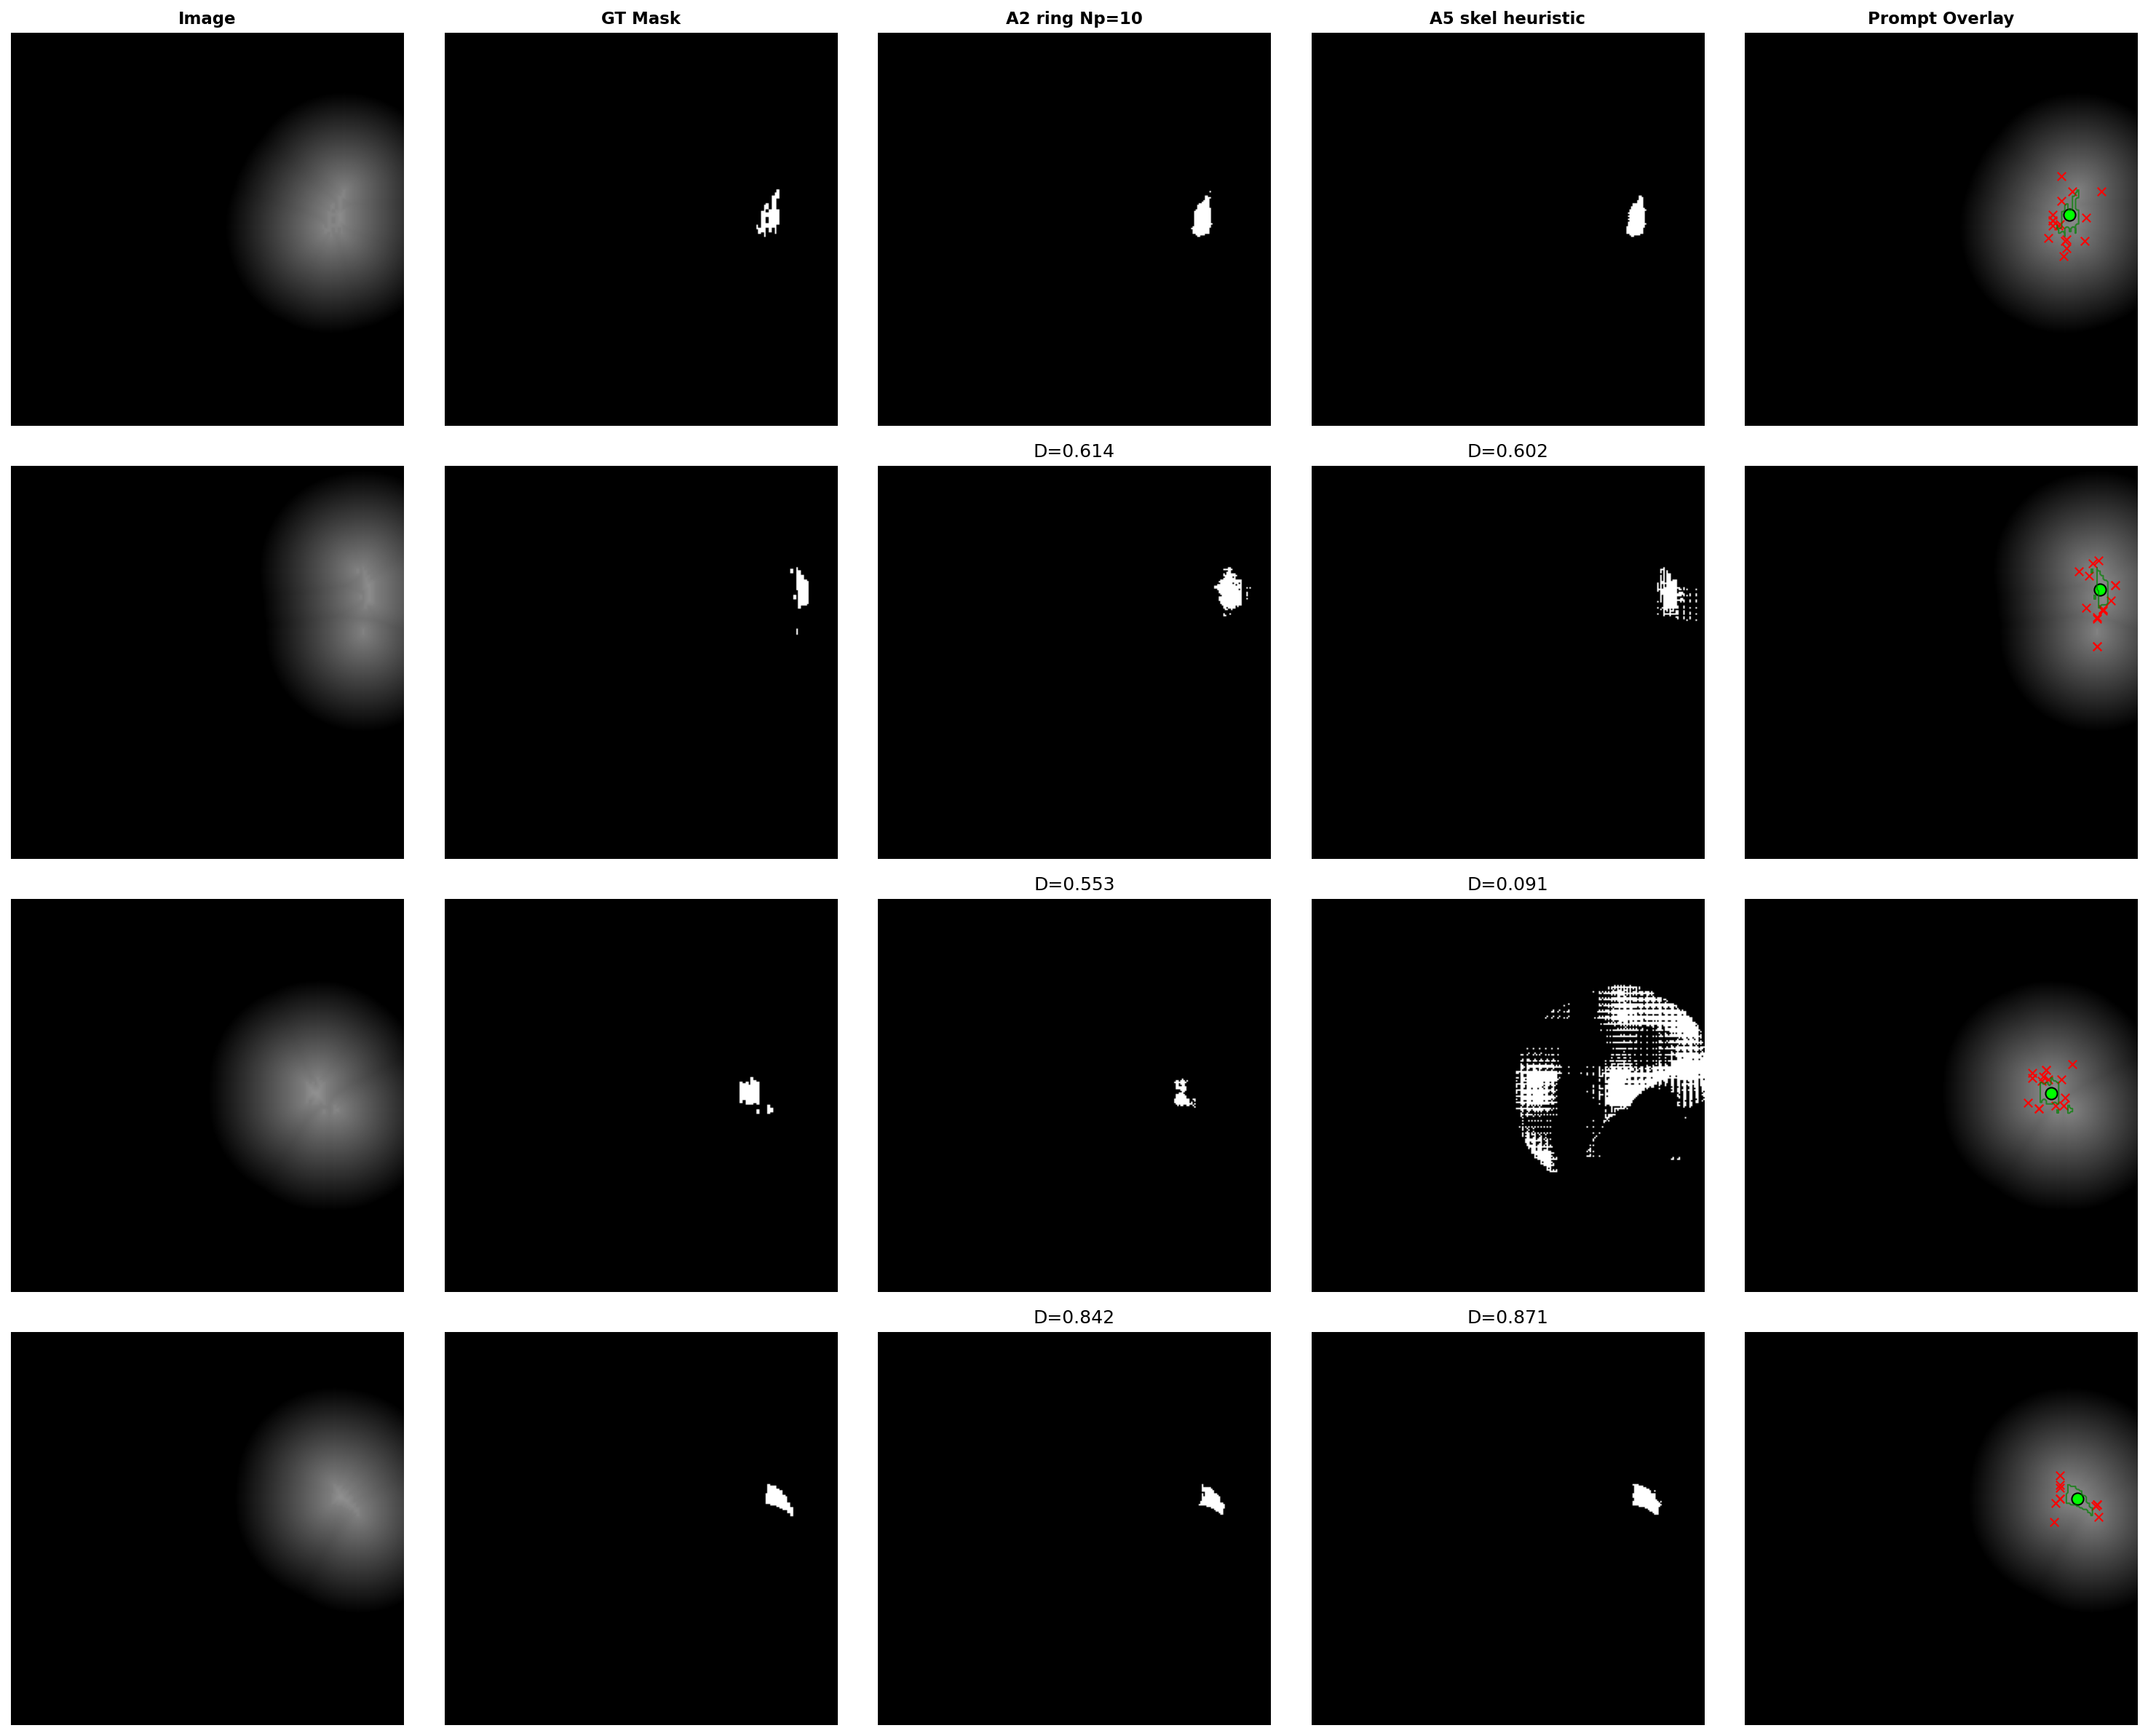

In [69]:
# Show comparison figure
from IPython.display import Image, display
import os

comp_path = 'figures/pilot/comparison_examples.png'
if os.path.isfile(comp_path):
    display(Image(filename=comp_path))
else:
    print(f'Comparison figure not found: {comp_path}')

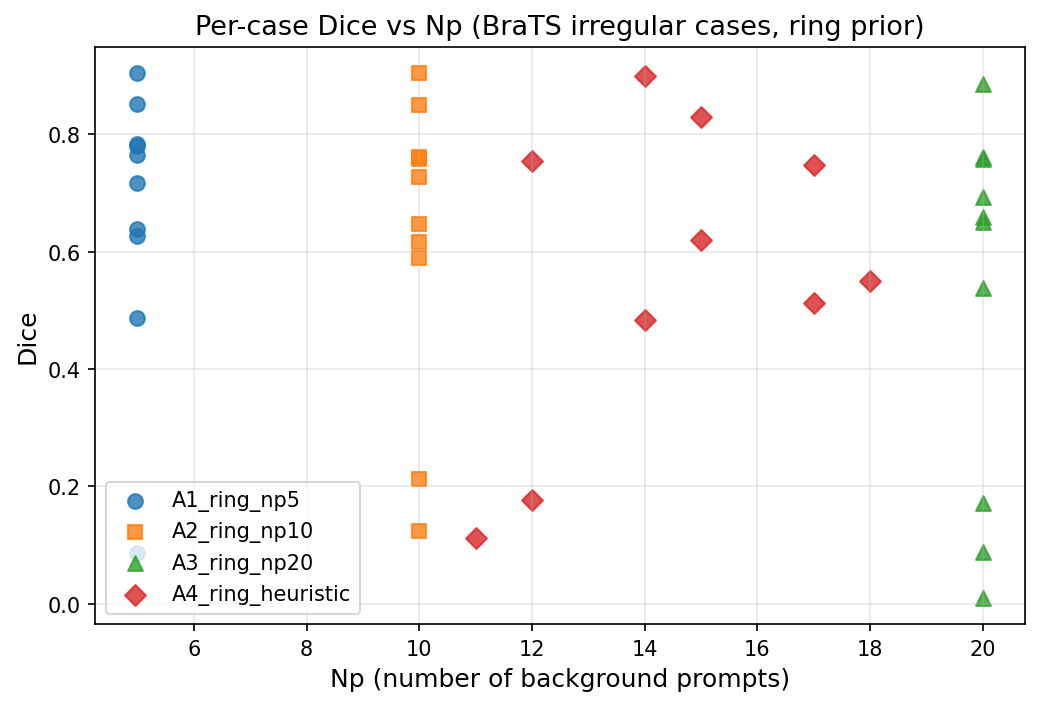

In [70]:
# Show Np vs Dice figure
np_dice_path = 'figures/pilot/np_vs_dice.png'
if os.path.isfile(np_dice_path):
    display(Image(filename=np_dice_path))
else:
    print(f'Np vs Dice figure not found: {np_dice_path}')

debug_BraTS20_Training_001_s088_tumor_A1_ring_np5.png


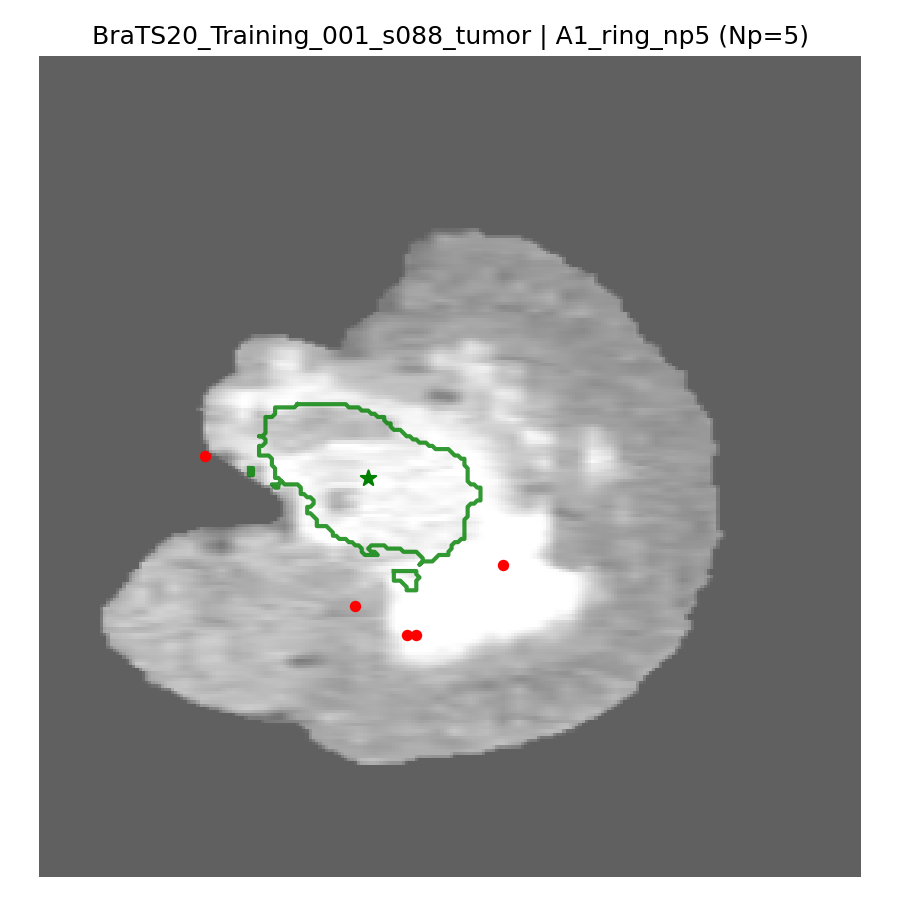

debug_BraTS20_Training_001_s088_tumor_A2_ring_np10.png


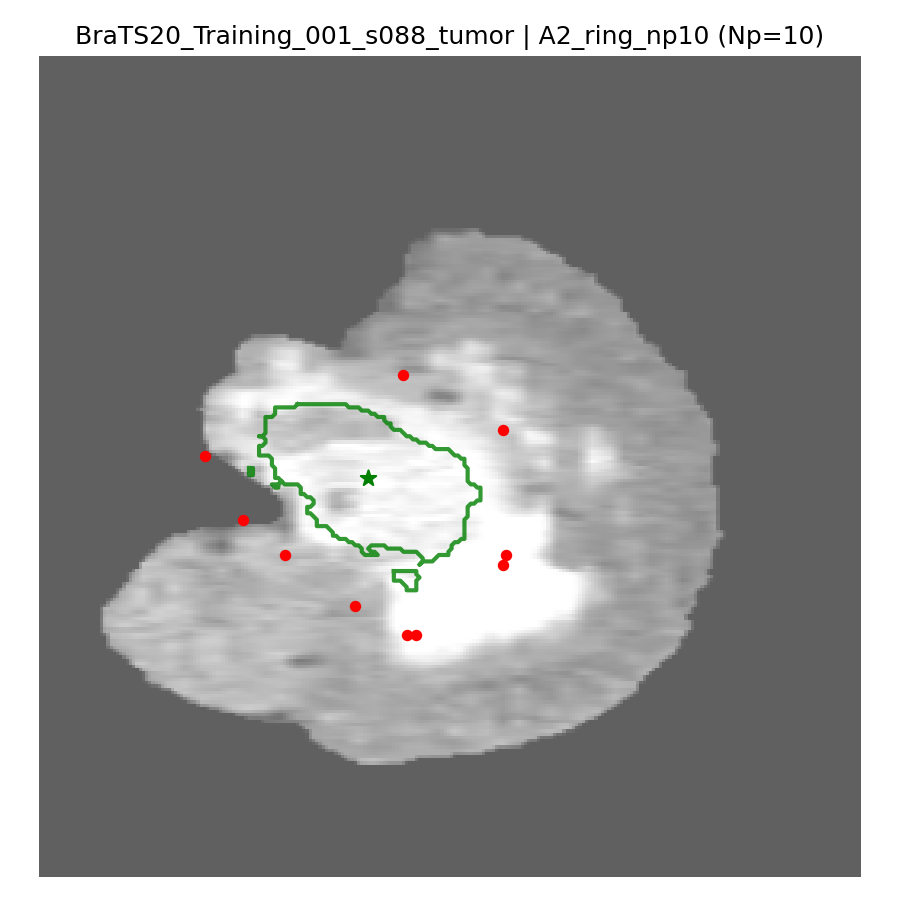

debug_BraTS20_Training_001_s088_tumor_A3_ring_np20.png


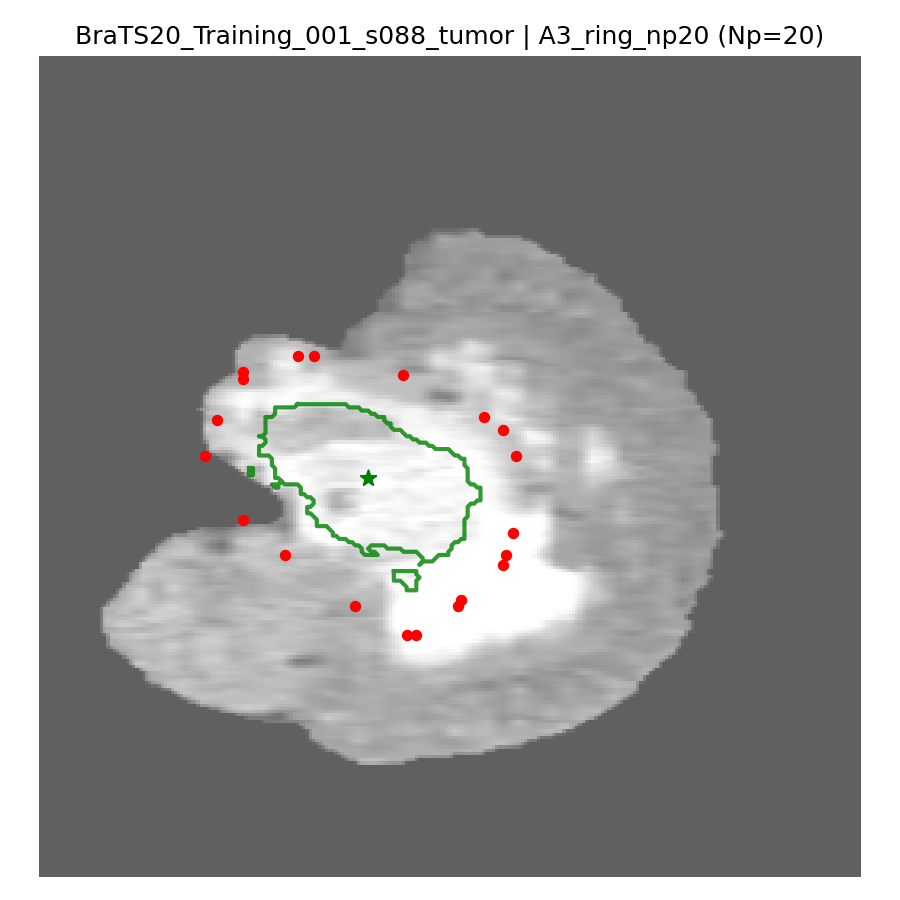

debug_BraTS20_Training_001_s088_tumor_A4_ring_heuristic.png


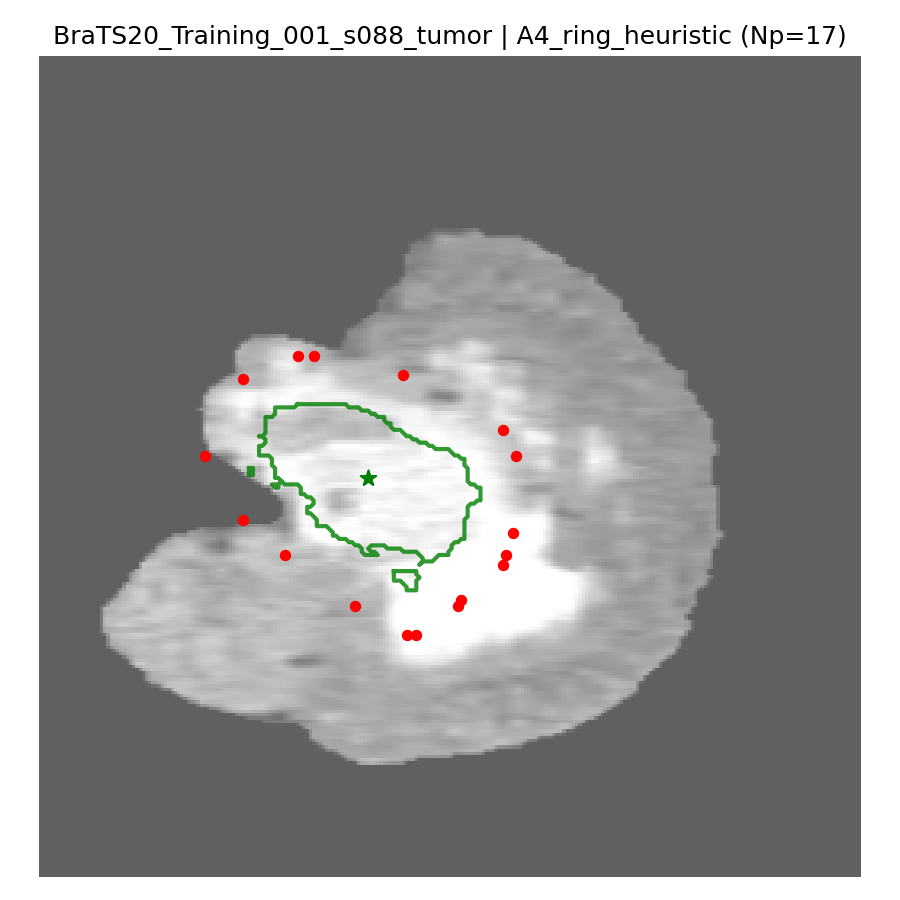

debug_BraTS20_Training_001_s088_tumor_A5_skel_heuristic.png


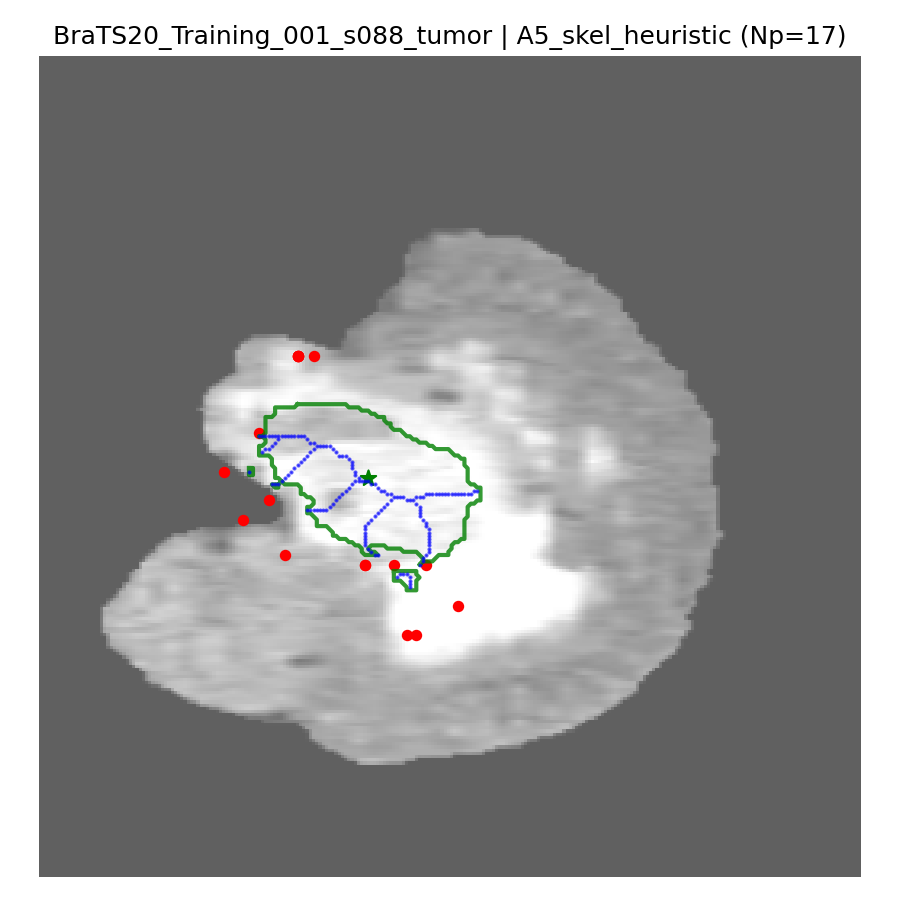

debug_BraTS20_Training_001_s088_tumor_A6_skel_np10.png


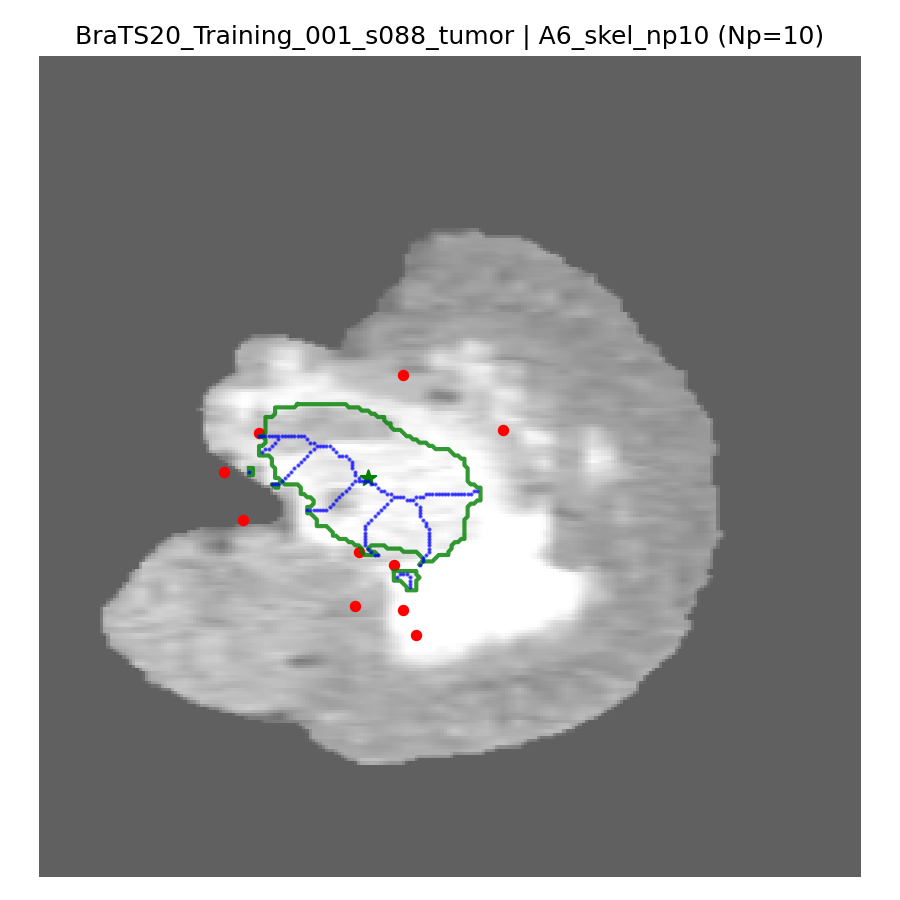

In [71]:
# Show some debug overlays
import glob
from IPython.display import Image, display

debug_files = sorted(glob.glob('figures/pilot/debug_*.png'))[:6]
for f in debug_files:
    print(os.path.basename(f))
    display(Image(filename=f, width=400))

---
## 7. Package Outputs

In [72]:
import shutil

output_zip = '/kaggle/working/phase2_outputs.zip'

# Zip results, figures, logs, notes
!cd /kaggle/working/AdaFoB && zip -r {output_zip} results/ figures/ logs/ notes/ \
    -x '*/masks/*'

print(f'\nOutput zip: {output_zip}')
print('Download from the Kaggle "Output" tab on the right sidebar.')
!ls -lh {output_zip}

updating: results/ (stored 0%)
updating: results/README.md (deflated 12%)
updating: results/pilot/ (stored 0%)
updating: results/pilot/pilot_summary_stats.csv (deflated 59%)
updating: results/pilot/pilot_metrics.csv (deflated 84%)
updating: results/pilot/pilot_shape_features.csv (deflated 64%)
updating: figures/ (stored 0%)
updating: figures/README.md (deflated 19%)
updating: figures/pilot/ (stored 0%)
updating: figures/pilot/debug_BraTS20_Training_002_s078_tumor_A2_ring_np10.png (deflated 10%)
updating: figures/pilot/debug_BraTS20_Training_003_s168_tumor_A1_ring_np5.png (deflated 16%)
updating: figures/pilot/debug_BraTS20_Training_005_s160_tumor_A6_skel_np10.png (deflated 10%)
updating: figures/pilot/debug_BraTS20_Training_001_s088_tumor_A2_ring_np10.png (deflated 9%)
updating: figures/pilot/debug_BraTS20_Training_004_s163_tumor_A3_ring_np20.png (deflated 10%)
updating: figures/pilot/np_vs_dice.png (deflated 13%)
updating: figures/pilot/debug_BraTS20_Training_002_s078_tumor_A4_ring_he

In [73]:
# Optional: Commit and push results back to GitHub
# Uncomment below if you have GITHUB_TOKEN set and want to push from Kaggle.

# import os
# from kaggle_secrets import UserSecretsClient
# secrets = UserSecretsClient()
# token = secrets.get_secret('GITHUB_TOKEN')
# 
# !cd /kaggle/working/AdaFoB && \
#   git config user.email 'pilot@adafob.local' && \
#   git config user.name 'AdaFoB Pilot Bot' && \
#   git add results/ figures/ logs/ notes/ && \
#   git commit -m 'Phase 2 pilot results from Kaggle' && \
#   git push https://{token}@github.com/PhoenixEvo/AdaFoB.git main
# print('Pushed results to GitHub.')